# Cluster analysis

To characterize the spatial organization of the system, clusters are identified independently for round and elongated cells. Two cells are considered connected when they belong to the same phenotype and interact significantly according to the same overlap criterion used in the dynamics. Connectivity is transitive, and clusters are reconstructed independently for each saved configuration. Isolated cells are therefore retained as clusters of size one.

For each phenotype $\alpha\in\{R,E\}$, we denote by $N_\alpha$ the number of cells belonging to that phenotype and by $S_{1,\alpha}$ and $S_{2,\alpha}$ the sizes of the largest and second-largest clusters, respectively.

The size of the largest cluster can be normalized either by the total number of cells,

$$
\frac{S_{1,\alpha}}{N},
$$

or by the number of cells belonging to the corresponding phenotype,

$$
\frac{S_{1,\alpha}}{N_\alpha}.
$$

These quantities provide complementary information. The first measures the fraction of the entire system contained in the largest cluster of phenotype $\alpha$, whereas the second measures how strongly the population of that phenotype is organized into a single connected structure.

They are related through

$$
\frac{S_{1,\alpha}}{N}
=
\frac{N_\alpha}{N}
\frac{S_{1,\alpha}}{N_\alpha}.
$$

Thus, changes in the macroscopic size of a cluster may arise either from changes in the abundance of a phenotype or from changes in its internal spatial organization.

To quantify the relative dominance of the largest cluster over the second-largest one, we define

$$
\psi_\alpha
=
\frac{S_{1,\alpha}-S_{2,\alpha}}
{S_{1,\alpha}+S_{2,\alpha}}.
$$

Values of $\psi_\alpha$ close to one indicate a strongly dominant largest cluster, whereas smaller values indicate that the two largest structures have comparable sizes.

In addition to the largest clusters, we analyze the fragmentation of each population through the number of clusters, the fraction of isolated cells, and the distribution of finite-cluster sizes. For elongated clusters, their internal polar and nematic order are also available, together with observables describing the collective motion of each cluster.

The aim of this analysis is to determine how the spatial organization of the round and elongated populations changes across the morphological transition previously identified from the elongated fraction $f_E$.

## Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

## Load and inspect data
We start by loading and inspecting the processed cluster data.

In [2]:
DATA_DIR = "data/clusters"

time_series = pd.read_parquet(
    f"{DATA_DIR}/cluster_time_series.parquet"
)

snapshots = pd.read_parquet(
    f"{DATA_DIR}/cluster_snapshots.parquet"
)

size_counts = pd.read_parquet(
    f"{DATA_DIR}/cluster_size_counts.parquet"
)

raw = pd.read_parquet(
    f"{DATA_DIR}/cluster_raw.parquet"
)

In [3]:
print("N values:")
print(sorted(snapshots["N"].unique()))

print("\nrho values by N:")
for N, group in snapshots.groupby("N"):
    print(N, sorted(group["rho"].unique()))

print("\nNumber of seeds by N and rho:")
display(
    snapshots.groupby(["N", "rho"])["seed"]
    .nunique()
    .unstack()
)

N values:
[np.int64(10000)]

rho values by N:
10000 [np.float64(0.8), np.float64(0.81), np.float64(0.82), np.float64(0.83), np.float64(0.84), np.float64(0.85), np.float64(0.86), np.float64(0.87)]

Number of seeds by N and rho:


rho,0.80,0.81,0.82,0.83,0.84,0.85,0.86,0.87
N,,,,,,,,
10000,32,32,32,32,32,32,32,32


In [4]:
print("Phenotypes:")
print(time_series["phenotype"].unique())

print("\nTime series steps:")
print("min =", time_series["step"].min())
print("max =", time_series["step"].max())
print("number of unique steps =", time_series["step"].nunique())

print("\nSnapshots steps:")
print("min =", snapshots["step"].min())
print("max =", snapshots["step"].max())
print("number of unique steps =", snapshots["step"].nunique())

print("\nFirst time-series steps:")
print(sorted(time_series["step"].unique())[:20])

print("\nFirst snapshot steps:")
print(sorted(snapshots["step"].unique())[:20])

Phenotypes:
<ArrowStringArray>
['elongated', 'round']
Length: 2, dtype: str

Time series steps:
min = 0
max = 80000
number of unique steps = 801

Snapshots steps:
min = 0
max = 80000
number of unique steps = 81

First time-series steps:
[np.int64(0), np.int64(100), np.int64(200), np.int64(300), np.int64(400), np.int64(500), np.int64(600), np.int64(700), np.int64(800), np.int64(900), np.int64(1000), np.int64(1100), np.int64(1200), np.int64(1300), np.int64(1400), np.int64(1500), np.int64(1600), np.int64(1700), np.int64(1800), np.int64(1900)]

First snapshot steps:
[np.int64(0), np.int64(1000), np.int64(2000), np.int64(3000), np.int64(4000), np.int64(5000), np.int64(6000), np.int64(7000), np.int64(8000), np.int64(9000), np.int64(10000), np.int64(11000), np.int64(12000), np.int64(13000), np.int64(14000), np.int64(15000), np.int64(16000), np.int64(17000), np.int64(18000), np.int64(19000)]


In [5]:
display(
    time_series
    .groupby(["rho", "seed"])["step"]
    .agg(["min", "max", "nunique"])
    .groupby("rho")
    .agg(["min", "max"])
)

min        max        nunique     
     min max    min    max     min  max
rho                                    
0.80   0   0  80000  80000     801  801
0.81   0   0  80000  80000     801  801
0.82   0   0  80000  80000     801  801
0.83   0   0  80000  80000     801  801
0.84   0   0  80000  80000     801  801
0.85   0   0  80000  80000     801  801
0.86   0   0  80000  80000     801  801
0.87   0   0  80000  80000     801  801

## Time evolution of cluster structure

We first study how the cluster structure develops from the initially round configuration.

For each phenotype, the fraction of the total system contained in its largest cluster can be written as

$$
\frac{S_{1,\alpha}}{N}
=
\frac{N_\alpha}{N}
\frac{S_{1,\alpha}}{N_\alpha}.
$$

This decomposition allows us to distinguish two contributions to the growth or disappearance of a macroscopic cluster: changes in the abundance of the corresponding phenotype, $N_\alpha/N$, and changes in the connectivity of that population, measured by $S_{1,\alpha}/N_\alpha$.

We therefore examine the time evolution of these quantities separately for round and elongated cells.

In [6]:
# Average over seeds at each time
# We group by density, step, and phenotype,
# and then compute the mean of the fraction of phenotype and the mean of S1/N,
# and the mean of S1/Nphenotype, and the mean of the number of clusters.
cluster_time = (
    time_series
    .groupby(["rho", "step", "phenotype"])
    .agg(
        fraction_phenotype_mean=("fraction_phenotype", "mean"),
        S1_over_N_mean=("S1_over_N", "mean"),
        S1_over_Nphenotype_mean=("S1_over_Nphenotype", "mean"),
        number_of_clusters_mean=("number_of_clusters", "mean"),
    )
    .reset_index()
)

cluster_time.head()

cluster_time.head()

,rho,step,phenotype,fraction_phenotype_mean,S1_over_N_mean,S1_over_Nphenotype_mean,number_of_clusters_mean
0,0.8,0,elongated,0.000000,0.000000,NaN,0.00000
1,0.8,0,round,1.000000,0.007010,0.007010,1022.59375
2,0.8,100,elongated,0.003663,0.000240,0.067752,29.84375
3,0.8,100,round,0.996337,0.008042,0.008071,2102.18750
4,0.8,200,elongated,0.005865,0.000347,0.060160,44.59375


We start plotting $\frac{S_{1,\alpha}}{N}$:

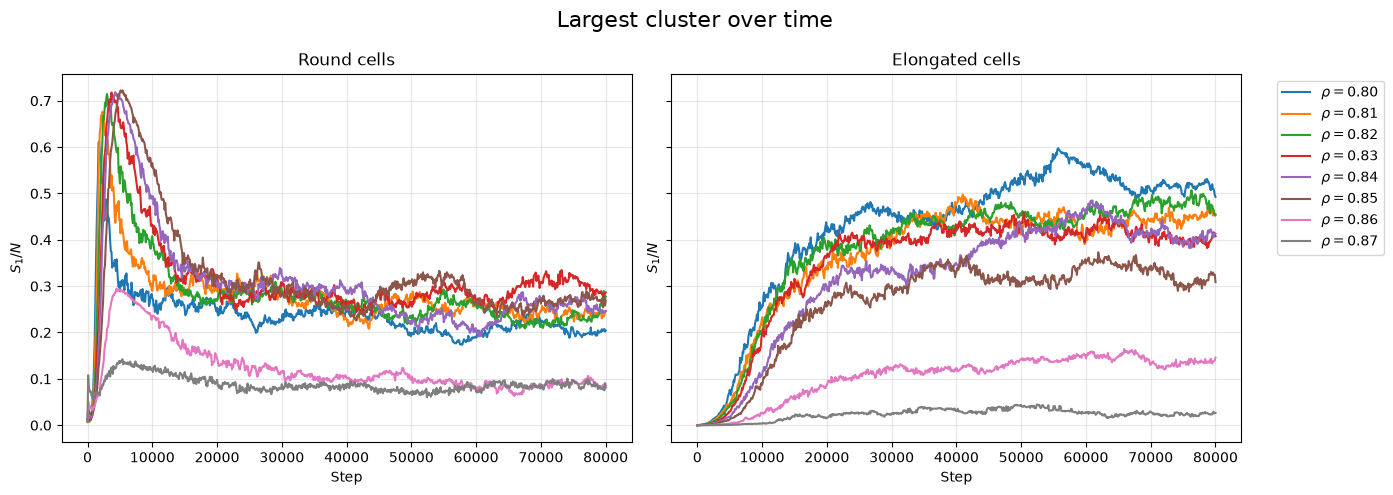

In [7]:
# Plot the largest cluster over time for each phenotype and density
fig, axs = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    sharex=True,
    sharey=True,
)

phenotypes = ["round", "elongated"]

titles = {
    "round": "Round cells",
    "elongated": "Elongated cells",
}

# For each phenotype, plot the largest cluster over time for each density
for ax, phenotype in zip(axs, phenotypes):

    df_pheno = cluster_time[
        cluster_time["phenotype"] == phenotype
    ]

    for rho, df_rho in df_pheno.groupby("rho"):

        ax.plot(
            df_rho["step"],
            df_rho["S1_over_N_mean"],
            label=fr"$\rho={rho:.2f}$",
        )

    ax.set_title(titles[phenotype])
    ax.set_xlabel("Step")
    ax.set_ylabel(r"$S_1/N$")
    ax.grid(alpha=0.3)

axs[-1].legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)

graph_title = "Largest cluster over time"
fig.suptitle(graph_title, fontsize=16)

rout_title = graph_title.lower().replace(" ", "_")

folder_name = "figures/clusters"

if not os.path.exists(folder_name):
    os.makedirs(folder_name)

plt.tight_layout()

plt.savefig(
    f"{folder_name}/{rout_title}.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

For elongated cells, the fraction of the total system contained in the largest cluster decreases at the highest densities. This behavior is expected to be closely related to the suppression of the elongated population observed previously through $f_E$.

The behavior of round cells is qualitatively different. Although $S_{1,R}/N$ initially increases with density (compare $\rho=0.80$ and $\rho=0.85$), it decreases again for the highest densities, particularly around $\rho=0.86$ and $\rho=0.87$. This is not simply explained by the phenotypic composition, since these densities correspond to systems dominated by round cells.

This suggests that a high fraction of round cells does not necessarily imply that they form a single macroscopic connected structure. In particular, the suppression of elongation at high density may result from geometric constraints even in the absence of a dominant interacting cluster of round cells.

To separate changes in phenotypic abundance from changes in connectivity, we now examine $N_\alpha/N$ and $S_{1,\alpha}/N_\alpha$ independently.

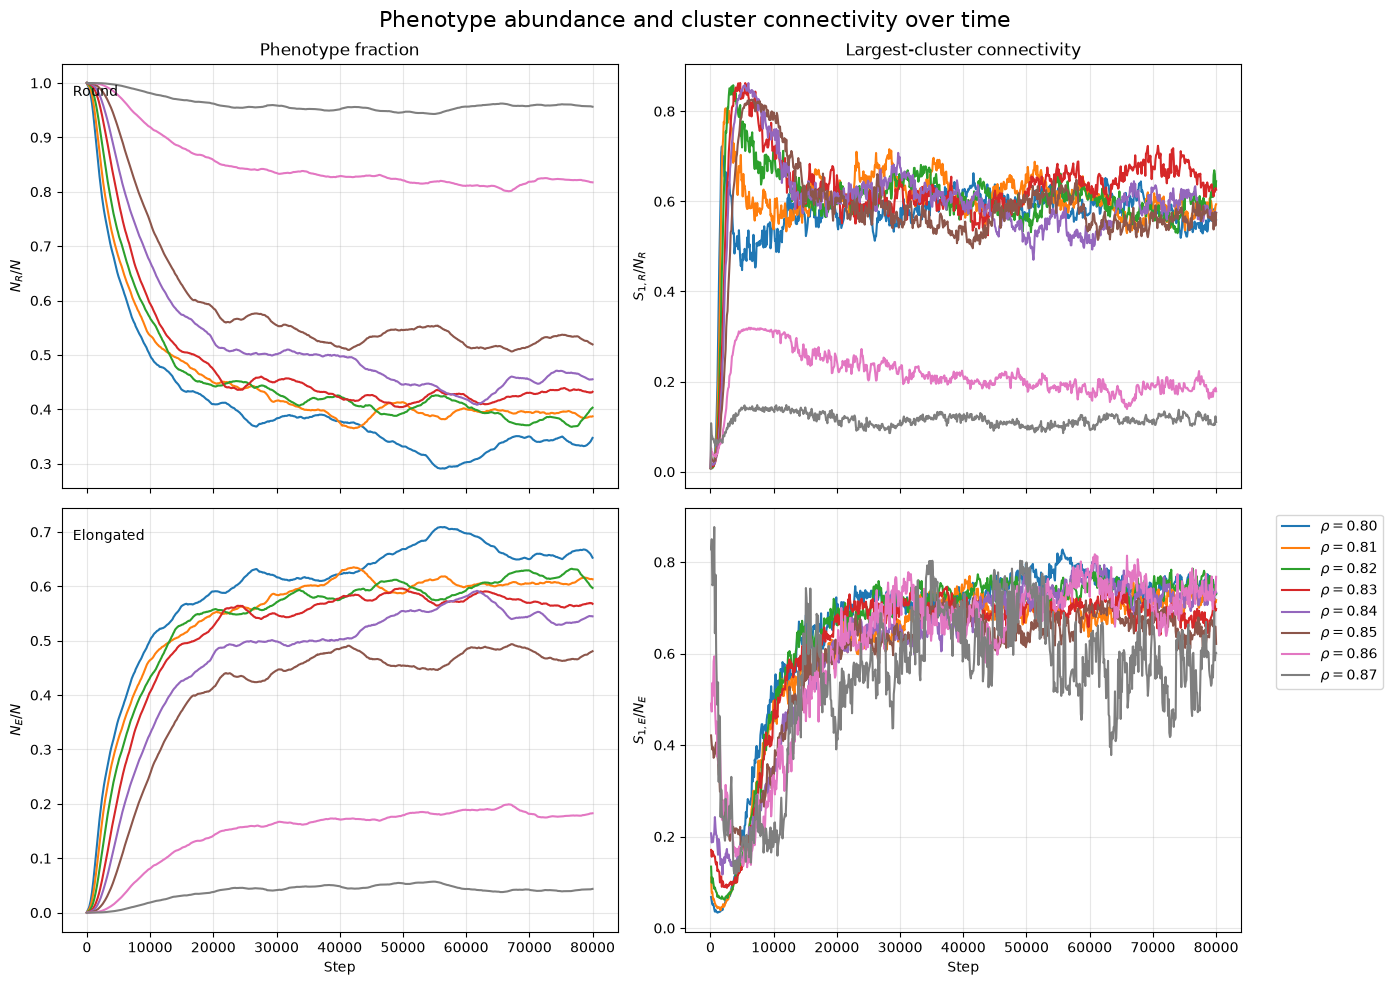

In [8]:
# Plot the fraction of each phenotype and the fraction of the 
# phenotype in its largest cluster over time for each density
fig, axs = plt.subplots(
    2,
    2,
    figsize=(14, 10),
    sharex=True,
)

phenotypes = ["round", "elongated"]

# For each phenotype, plot the fraction of each phenotype and the fraction of the
# phenotype in its largest cluster over time for each density
for row, phenotype in enumerate(phenotypes):

    df_pheno = cluster_time[
        cluster_time["phenotype"] == phenotype
    ]

    for rho, df_rho in df_pheno.groupby("rho"):

        # Fraction of cells of the phenotype
        axs[row, 0].plot(
            df_rho["step"],
            df_rho["fraction_phenotype_mean"],
            label=fr"$\rho={rho:.2f}$",
        )

        # Fraction of the phenotype in its largest cluster
        axs[row, 1].plot(
            df_rho["step"],
            df_rho["S1_over_Nphenotype_mean"],
            label=fr"$\rho={rho:.2f}$",
        )


axs[0, 0].set_title("Phenotype fraction")
axs[0, 1].set_title("Largest-cluster connectivity")

axs[0, 0].set_ylabel(r"$N_R/N$")
axs[0, 1].set_ylabel(r"$S_{1,R}/N_R$")

axs[1, 0].set_ylabel(r"$N_E/N$")
axs[1, 1].set_ylabel(r"$S_{1,E}/N_E$")

for ax in axs[1, :]:
    ax.set_xlabel("Step")

for ax in axs.flat:
    ax.grid(alpha=0.3)

# Add text labels to the subplots
axs[0, 0].text(
    0.02,
    0.95,
    "Round",
    transform=axs[0, 0].transAxes,
    va="top",
)

# Add text labels to the subplots
axs[1, 0].text(
    0.02,
    0.95,
    "Elongated",
    transform=axs[1, 0].transAxes,
    va="top",
)

# Add legends to the subplots
axs[1, 1].legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)

graph_title = "Phenotype abundance and cluster connectivity over time"
fig.suptitle(graph_title, fontsize=16)

rout_title = graph_title.lower().replace(" ", "_")

folder_name = "figures/clusters"

if not os.path.exists(folder_name):
    os.makedirs(folder_name)

plt.tight_layout()

plt.savefig(
    f"{folder_name}/{rout_title}.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

The decomposition shows that phenotypic abundance and cluster connectivity behave quite differently.

For round cells, $N_R/N$ increases strongly with density, but at the highest densities $S_{1,R}/N_R$ decreases. So even though most cells are round, they do not form a large interacting cluster according to our current definition.

My guess is that elongation is still blocked by crowding and spatial constraints, even without a giant interaction-based cluster. If we used a more geometric cluster definition, for example connecting cells within a distance $R$, we might actually recover a giant cluster in this regime.

For elongated cells, most of the density dependence comes from $N_E/N$. When a substantial elongated population exists, a large fraction of it usually belongs to the largest elongated cluster.

So the decrease of $S_{1,E}/N$ at high density seems to be mainly due to the disappearance of elongated cells, rather than to strong fragmentation of the elongated population.

At very early times, and also at the highest densities, $S_{1,E}/N_E$ should be interpreted carefully because $N_E$ is very small.

## Steady state cluster structure

### Largest cluster size

To compare the cluster structure between densities, we average the cluster observables over the final $10\%$ of each realization. As in the order-parameter analysis, this window is used to obtain more stable late-time estimates without assuming that every realization has reached a fully stationary state.

We first average over time independently for each seed, and then average over realizations.

In [9]:
# Take the last 10% of the simulation steps as the steady-state window
steady_fraction = 0.10

max_step = snapshots["step"].max()
steady_start = max_step * (1 - steady_fraction)

cluster_late = snapshots[
    snapshots["step"] >= steady_start
].copy()

print("Late-time window starts at step:", steady_start)

Late-time window starts at step: 72000.0


In [10]:
# Compute the mean of the fraction of phenotype and the mean of S1/N and S1/Nphenotype
# over the late-time window for each seed, density, and phenotype
cluster_seed_stats = (
    cluster_late
    .groupby(["N", "rho", "seed", "phenotype"])
    .agg(
        fraction_phenotype=("fraction_phenotype", "mean"),

        S1_over_N=("S1_over_N", "mean"),
        S1_over_Nphenotype=("S1_over_Nphenotype", "mean"),

        S2_over_N=("S2_over_N", "mean"),
        S2_over_Nphenotype=("S2_over_Nphenotype", "mean"),

        psi=("psi", "mean"),
    )
    .reset_index()
)

cluster_seed_stats.head()

,N,rho,seed,phenotype,fraction_phenotype,S1_over_N,S1_over_Nphenotype,S2_over_N,S2_over_Nphenotype,psi
0,10000,0.8,12944511869278,elongated,0.991099,0.960704,0.969317,0.000963,0.000973,0.997993
1,10000,0.8,12944511869278,round,0.008901,0.005630,0.610992,0.000580,0.082133,0.755049
2,10000,0.8,78804909138230,elongated,0.758370,0.695531,0.916642,0.010099,0.013322,0.971256
3,10000,0.8,78804909138230,round,0.241630,0.186123,0.790156,0.036074,0.128152,0.727378
4,10000,0.8,170902461924754,elongated,0.725222,0.591642,0.814044,0.025173,0.034990,0.917220


In [11]:
# Compute the mean of the fraction of phenotype and the mean of S1/N and S1/Nphenotype
cluster_rho_stats = (
    cluster_seed_stats
    .groupby(["N", "rho", "phenotype"])
    .agg(
        fraction_phenotype=("fraction_phenotype", "mean"),

        S1_over_N=("S1_over_N", "mean"),
        S1_over_Nphenotype=("S1_over_Nphenotype", "mean"),

        S2_over_N=("S2_over_N", "mean"),
        S2_over_Nphenotype=("S2_over_Nphenotype", "mean"),

        psi=("psi", "mean"),
    )
    .reset_index()
)

cluster_rho_stats

,N,rho,phenotype,fraction_phenotype,S1_over_N,S1_over_Nphenotype,S2_over_N,S2_over_Nphenotype,psi
0,10000,0.80,elongated,0.658980,0.514069,0.751594,0.041927,0.070765,0.809127
1,10000,0.80,round,0.341020,0.202799,0.555530,0.067896,0.185953,0.471453
2,10000,0.81,elongated,0.608749,0.448598,0.716406,0.044895,0.079014,0.781797
3,10000,0.81,round,0.391251,0.240339,0.580154,0.068070,0.179785,0.499008
4,10000,0.82,elongated,0.617800,0.479837,0.752324,0.030834,0.055921,0.848971
5,10000,0.82,round,0.382200,0.234535,0.584782,0.078754,0.204245,0.463462
6,10000,0.83,elongated,0.565277,0.404279,0.687389,0.047703,0.086582,0.756287
7,10000,0.83,round,0.434723,0.303356,0.658681,0.058609,0.138382,0.611788
8,10000,0.84,elongated,0.537704,0.404831,0.725584,0.033478,0.069869,0.793715
9,10000,0.84,round,0.462296,0.255830,0.589022,0.074126,0.169992,0.499168


We first consider the fraction of the whole system contained in the largest cluster of each phenotype,

$$
\frac{S_{1,\alpha}}{N}.
$$

This gives a direct measure of the macroscopic importance of the largest round and elongated structures as density is varied.

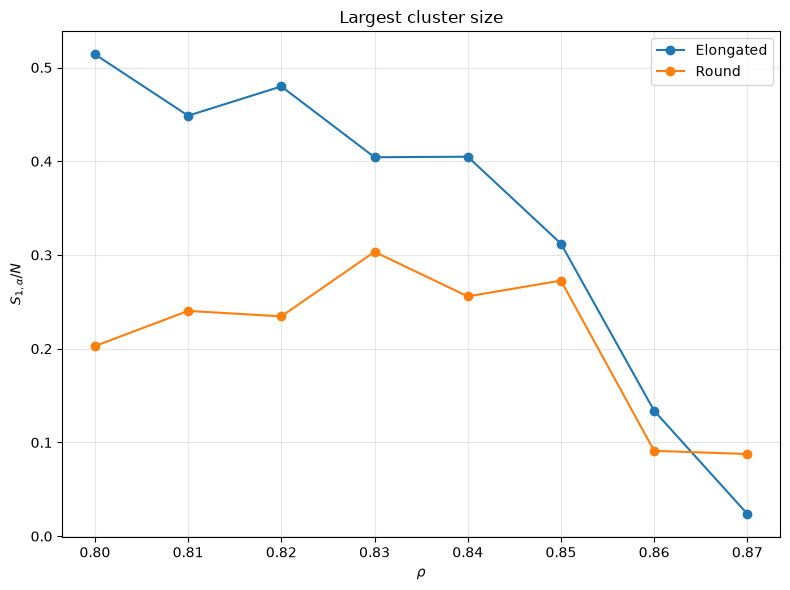

In [12]:
# Plot the largest cluster size as a function of density for each phenotype
plt.figure(figsize=(8, 6))

for phenotype, df_pheno in cluster_rho_stats.groupby("phenotype"):

    plt.plot(
        df_pheno["rho"],
        df_pheno["S1_over_N"],
        marker="o",
        label=phenotype.capitalize(),
    )

plt.xlabel(r"$\rho$")
plt.ylabel(r"$S_{1,\alpha}/N$")

plt.legend()
plt.grid(alpha=0.3)

graph_title = "Largest cluster size"

plt.title(graph_title)

rout_title = graph_title.lower().replace(" ", "_")

folder_name = "figures/clusters"

if not os.path.exists(folder_name):
    os.makedirs(folder_name)

plt.tight_layout()

plt.savefig(
    f"{folder_name}/{rout_title}.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

### Largest-cluster dominance

The size of the largest cluster does not tell us whether it is clearly dominant over the remaining structures. We therefore also consider

$$
\psi_\alpha
=
\frac{S_{1,\alpha}-S_{2,\alpha}}
{S_{1,\alpha}+S_{2,\alpha}}.
$$

A value close to one corresponds to a clearly dominant largest cluster, while smaller values indicate that the two largest clusters have more comparable sizes.

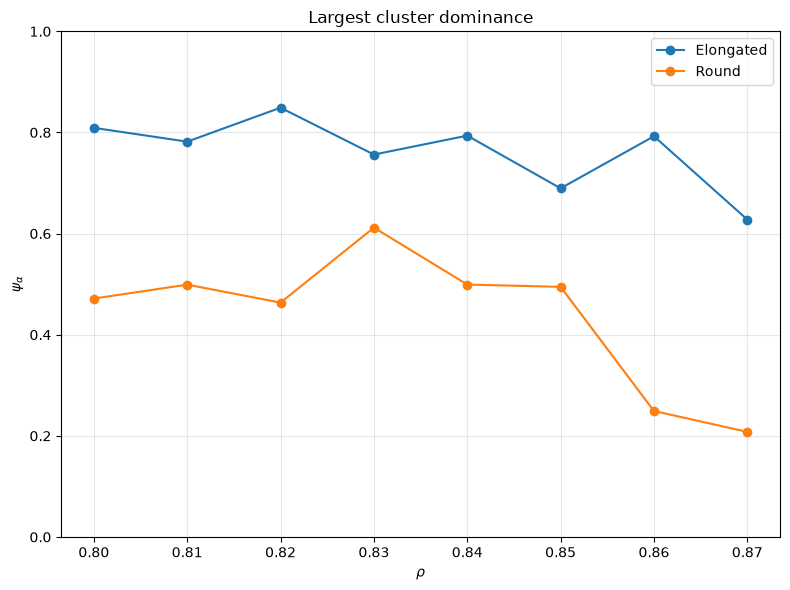

In [13]:
plt.figure(figsize=(8, 6))

for phenotype, df_pheno in cluster_rho_stats.groupby("phenotype"):

    plt.plot(
        df_pheno["rho"],
        df_pheno["psi"],
        marker="o",
        label=phenotype.capitalize(),
    )

plt.xlabel(r"$\rho$")
plt.ylabel(r"$\psi_\alpha$")
plt.ylim(0, 1)

plt.legend()
plt.grid(alpha=0.3)

graph_title = "Largest cluster dominance"
plt.title(graph_title)

rout_title = graph_title.lower().replace(" ", "_")

folder_name = "figures/clusters"

if not os.path.exists(folder_name):
    os.makedirs(folder_name)

plt.tight_layout()

plt.savefig(
    f"{folder_name}/{rout_title}.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

For elongated cells, $\psi_E$ remains relatively large over the whole density range, suggesting that the largest elongated cluster is usually clearly dominant over the second-largest one.

For round cells, $\psi_R$ decreases strongly at $\rho=0.86$ and $\rho=0.87$. Together with the decrease of $S_{1,R}/N_R$, this suggests that the round population becomes less dominated by a single connected structure at high density.

However, $\psi_R$ alone does not tell us whether this corresponds to a few comparable clusters or to fragmentation into many smaller clusters. To check this, we next look at the number of clusters.

## Fragmentation

The previous results suggest that the round population becomes less dominated by a single connected structure at high density. We now ask whether this corresponds to a fragmentation into a larger number of clusters.

### Time evolution of the number of clusters

We first look at the total number of clusters, $N_c^\alpha$, for each phenotype as a function of time.

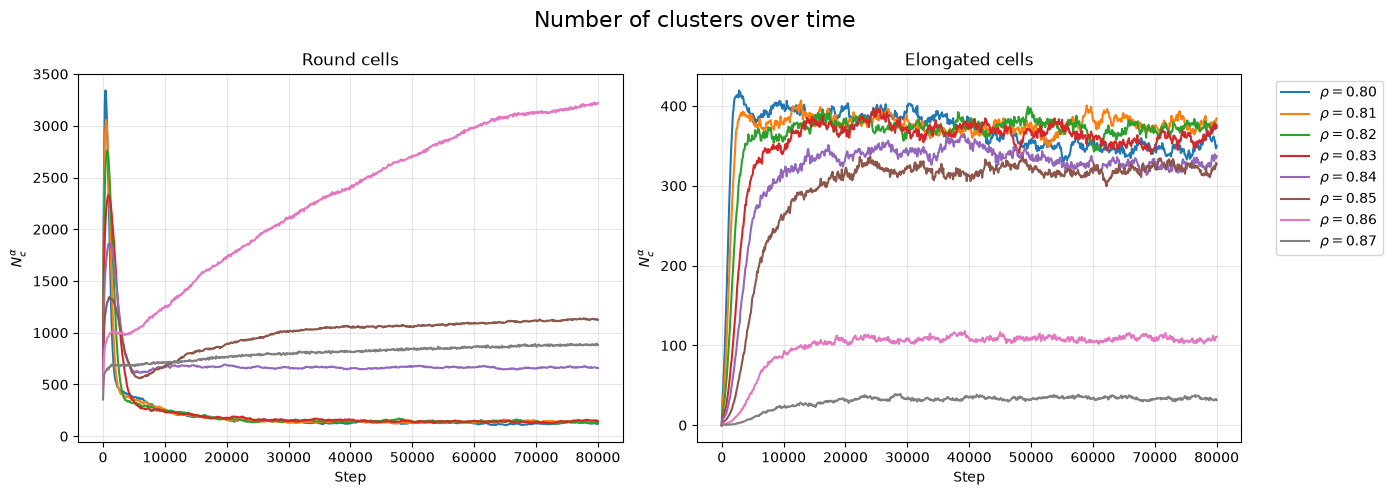

In [14]:
# Plot the number of clusters over time for each phenotype and density
fig, axs = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    sharex=True,
)

phenotypes = ["round", "elongated"]

titles = {
    "round": "Round cells",
    "elongated": "Elongated cells",
}

# For each phenotype, plot the number of clusters over time for each density
for ax, phenotype in zip(axs, phenotypes):

    df_pheno = cluster_time[
        cluster_time["phenotype"] == phenotype
    ]

    for rho, df_rho in df_pheno.groupby("rho"):

        ax.plot(
            df_rho["step"],
            df_rho["number_of_clusters_mean"],
            label=fr"$\rho={rho:.2f}$",
        )

    ax.set_title(titles[phenotype])
    ax.set_xlabel("Step")
    ax.set_ylabel(r"$N_c^\alpha$")
    ax.grid(alpha=0.3)

axs[-1].legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)

graph_title = "Number of clusters over time"
fig.suptitle(graph_title, fontsize=16)

rout_title = graph_title.lower().replace(" ", "_")

folder_name = "figures/clusters"

if not os.path.exists(folder_name):
    os.makedirs(folder_name)

plt.tight_layout()

plt.savefig(
    f"{folder_name}/{rout_title}.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

The number of clusters shows a strong change in the organization of the round population.

At lower densities, the number of round clusters initially increases but then decreases strongly as the system evolves. Around $\rho=0.85$ and especially $\rho=0.86$, many more round clusters remain at late times. In particular, at $\rho=0.86$ the number of round clusters continues increasing during most of the simulation, which is consistent with the low values of $S_{1,R}/N_R$ and $\psi_R$ found before.

Interestingly, $\rho=0.87$ contains fewer round clusters than $\rho=0.86$, even though the round fraction is larger. This suggests that the strongest fragmentation may occur around the transition region rather than simply increasing with density.

For elongated cells, the number of clusters decreases strongly at high density. However, this is partly expected because the total elongated population also becomes very small, so the raw number of clusters alone is not enough to quantify their fragmentation.

In [15]:
cluster_late["clusters_per_cell"] = (
    cluster_late["number_of_clusters"]
    / cluster_late["number_of_cells_phenotype"]
)

fragmentation_seed_stats = (
    cluster_late
    .groupby(["N", "rho", "seed", "phenotype"])
    .agg(
        clusters_per_cell=("clusters_per_cell", "mean"),
    )
    .reset_index()
)

fragmentation_rho_stats = (
    fragmentation_seed_stats
    .groupby(["N", "rho", "phenotype"])
    .agg(
        clusters_per_cell=("clusters_per_cell", "mean"),
    )
    .reset_index()
)

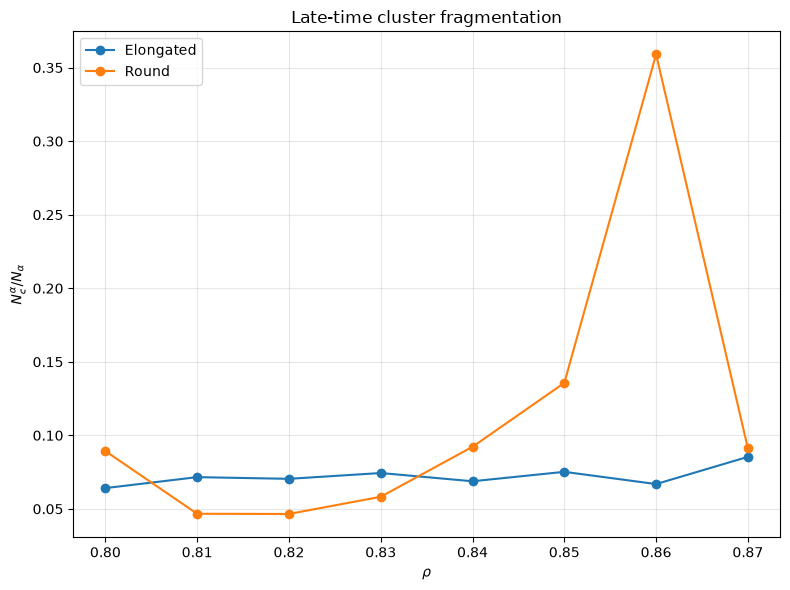

In [16]:
plt.figure(figsize=(8, 6))

for phenotype, df_pheno in fragmentation_rho_stats.groupby("phenotype"):

    plt.plot(
        df_pheno["rho"],
        df_pheno["clusters_per_cell"],
        marker="o",
        label=phenotype.capitalize(),
    )

plt.xlabel(r"$\rho$")
plt.ylabel(r"$N_c^\alpha/N_\alpha$")

plt.legend()
plt.grid(alpha=0.3)

graph_title = "Late-time cluster fragmentation"
plt.title(graph_title)

rout_title = graph_title.lower().replace(" ", "_")

folder_name = "figures/clusters"

if not os.path.exists(folder_name):
    os.makedirs(folder_name)

plt.tight_layout()

plt.savefig(
    f"{folder_name}/{rout_title}.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

The fragmentation of the round population changes strongly with density.

At lower densities, where a large elongated population develops, the round cells form relatively few clusters and a large fraction of them belongs to the largest one. One possibility is that the motion and organization of the elongated cells pushes the remaining round cells together, helping them form a larger connected structure.

Around $\rho=0.86$, the situation changes strongly. The normalized number of round clusters has a clear maximum, while $S_{1,R}/N_R$ and $\psi_R$ are small. My current interpretation is that this may be a geometric blocking regime: there is already little space available for elongation, but the round cells are still not dense enough to become strongly connected through our interaction criterion.

This is also the density where different realizations behave very differently. Some remain almost completely round, while others develop a substantial elongated population, so this seems to be a region where several different structures can appear.

At $\rho=0.87$, almost all cells remain round and the number of clusters decreases again. A possible explanation is that the higher density increases the number of contacts between round cells, joining the small components into larger ones. However, there is still no clearly dominant round cluster, as seen from the low values of $S_{1,R}/N_R$ and $\psi_R$.

## Internal order of elongated clusters

The global polar and nematic order parameters studied before do not tell us whether the elongated clusters are internally ordered. A low global order could arise either because the clusters themselves are disordered or because different ordered clusters point in different directions.

We therefore look at the polar and nematic order inside elongated clusters. Single-cell clusters are excluded, since their polar and nematic order are trivially equal to one.

We compare the size-weighted mean order of the elongated clusters with the order of the largest elongated cluster.

In [17]:
# Select elongated clusters in the late-time window
elongated_order_late = time_series[
    (time_series["phenotype"] == "elongated")
    & (time_series["step"] >= steady_start)
].copy()

# First average over time for each seed
elongated_order_seed = (
    elongated_order_late
    .groupby(["N", "rho", "seed"])
    .agg(
        weighted_polar=(
            "weighted_mean_polar_order_non_singleton",
            "mean",
        ),
        weighted_nematic=(
            "weighted_mean_nematic_order_non_singleton",
            "mean",
        ),
        largest_polar=(
            "largest_cluster_polar_order",
            "mean",
        ),
        largest_nematic=(
            "largest_cluster_nematic_order",
            "mean",
        ),
    )
    .reset_index()
)

# Then average over realizations
elongated_order_rho = (
    elongated_order_seed
    .groupby(["N", "rho"])
    .agg(
        weighted_polar=("weighted_polar", "mean"),
        weighted_nematic=("weighted_nematic", "mean"),
        largest_polar=("largest_polar", "mean"),
        largest_nematic=("largest_nematic", "mean"),
    )
    .reset_index()
)

elongated_order_rho

,N,rho,weighted_polar,weighted_nematic,largest_polar,largest_nematic
0,10000,0.80,0.640404,0.515189,0.626396,0.465671
1,10000,0.81,0.619211,0.477198,0.594471,0.425195
2,10000,0.82,0.645175,0.498511,0.632970,0.441796
3,10000,0.83,0.636533,0.540789,0.608023,0.486227
4,10000,0.84,0.634816,0.483948,0.618748,0.438010
5,10000,0.85,0.616546,0.542189,0.588757,0.486370
6,10000,0.86,0.646175,0.468244,0.622882,0.383562
7,10000,0.87,0.678818,0.591951,0.676876,0.545633


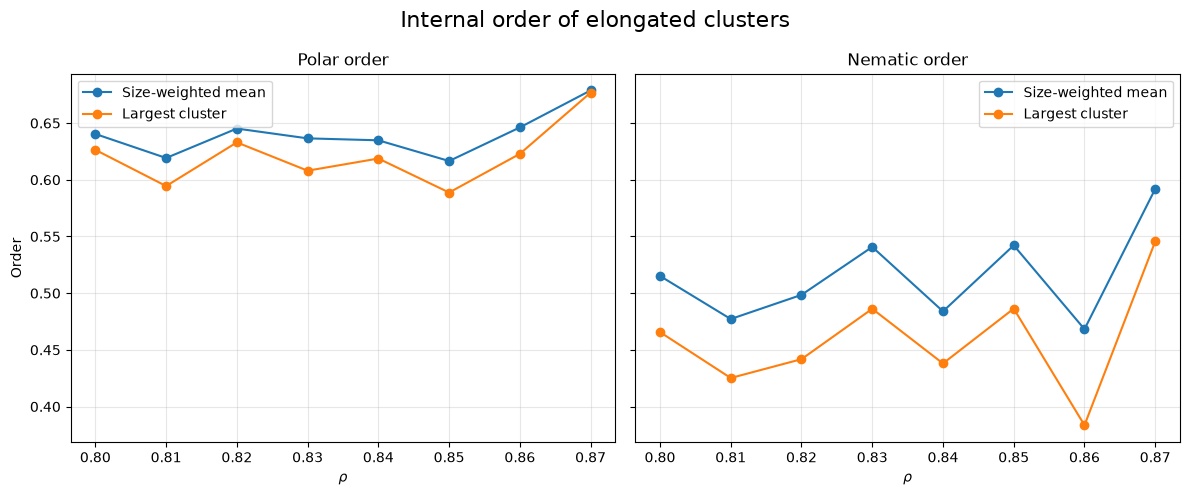

In [18]:
# Plot the polar and nematic order of elongated clusters as a function of density
fig, axs = plt.subplots(
    1,
    2,
    figsize=(12, 5),
    sharex=True,
    sharey=True,
)

# Polar order
axs[0].plot(
    elongated_order_rho["rho"],
    elongated_order_rho["weighted_polar"],
    marker="o",
    label="Size-weighted mean",
)

axs[0].plot(
    elongated_order_rho["rho"],
    elongated_order_rho["largest_polar"],
    marker="o",
    label="Largest cluster",
)

axs[0].set_title("Polar order")
axs[0].set_xlabel(r"$\rho$")
axs[0].set_ylabel("Order")
axs[0].grid(alpha=0.3)
axs[0].legend()


# Nematic order
axs[1].plot(
    elongated_order_rho["rho"],
    elongated_order_rho["weighted_nematic"],
    marker="o",
    label="Size-weighted mean",
)

axs[1].plot(
    elongated_order_rho["rho"],
    elongated_order_rho["largest_nematic"],
    marker="o",
    label="Largest cluster",
)

axs[1].set_title("Nematic order")
axs[1].set_xlabel(r"$\rho$")
axs[1].grid(alpha=0.3)
axs[1].legend()


graph_title = "Internal order of elongated clusters"
fig.suptitle(graph_title, fontsize=16)

rout_title = graph_title.lower().replace(" ", "_")

folder_name = "figures/clusters"

if not os.path.exists(folder_name):
    os.makedirs(folder_name)

plt.tight_layout()

plt.savefig(
    f"{folder_name}/{rout_title}.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

The internal order of elongated clusters changes relatively little with density.

The polar order remains around $0.6-0.7$ over most of the density range, both for the size-weighted average and for the largest cluster. This suggests that, whenever elongated clusters form, they remain internally quite ordered.

The nematic order is somewhat lower, and the largest cluster is generally slightly less nematically ordered than the size-weighted average.

Overall, the disappearance of the elongated state at high density does not seem to be caused by a progressive loss of internal cluster order. Instead, the main change appears to be the disappearance of the elongated population itself.

The values at $\rho=0.87$ should be interpreted carefully, since very few elongated cells remain and the corresponding clusters are small.

## Cluster motion

Finally, we look at how the motion of elongated clusters depends on their size.

For each cluster $\mathcal{C}$, we distinguish between its collective speed,

$$
V_{\mathcal{C}}
=
\left|
\frac{1}{|\mathcal{C}|}
\sum_{i\in\mathcal{C}}
\mathbf{v}_i
\right|,
$$

and the mean speed of its cells,

$$
\overline{v}_{\mathcal{C}}
=
\frac{1}{|\mathcal{C}|}
\sum_{i\in\mathcal{C}}
|\mathbf{v}_i|.
$$

Their ratio,

$$
C_{\mathcal{C}}
=
\frac{V_{\mathcal{C}}}
{\overline{v}_{\mathcal{C}}},
$$

gives a simple measure of motion coherence. Values close to one indicate that most of the cellular motion contributes to translation of the cluster, while smaller values indicate stronger cancellation of the individual cell velocities.

We study how these quantities change with cluster size.

In [19]:
# Compute the motion coherence of elongated clusters in the late-time window
elongated_motion = raw[
    (raw["phenotype"] == "elongated")
    & (raw["step"] >= steady_start)
    & (raw["size"] > 1)
].copy()

elongated_motion["motion_coherence"] = np.where(
    elongated_motion["mean_cell_speed"] > 0,
    elongated_motion["cluster_speed"]
    / elongated_motion["mean_cell_speed"],
    np.nan,
)

# Print the descriptive statistics of the motion coherence of elongated clusters
print(
    elongated_motion[
        [
            "size",
            "cluster_speed",
            "mean_cell_speed",
            "motion_coherence",
        ]
    ].describe()
)

                size  cluster_speed  mean_cell_speed  motion_coherence
count  155138.000000  155138.000000    155138.000000     155138.000000
mean       60.206345       0.729336         0.926202          0.791996
std       476.413623       0.279416         0.199824          0.254730
min         2.000000       0.001870         0.075411          0.002261
25%         2.000000       0.529242         0.829963          0.645593
50%         3.000000       0.780712         0.941391          0.928388
75%         7.000000       0.948731         1.034119          0.980114
max      9372.000000       1.603988         2.479679          1.000000


In [20]:
# Create logarithmic bins for the cluster sizes of elongated clusters
min_size = elongated_motion["size"].min()
max_size = elongated_motion["size"].max()

size_bins = np.unique(
    np.logspace(
        np.log10(min_size),
        np.log10(max_size + 1),
        18,
    ).astype(int)
)

# Assign the size bins to the elongated clusters
elongated_motion["size_bin"] = pd.cut(
    elongated_motion["size"],
    bins=size_bins,
    include_lowest=True,
)

In [21]:
# Compute the mean of the cluster speed, mean cell speed, and motion coherence
# for each density, seed, and size bin of elongated clusters
motion_size_seed = (
    elongated_motion
    .groupby(
        ["rho", "seed", "size_bin"],
        observed=True,
    )
    .agg(
        size_mean=("size", "mean"),
        cluster_speed=("cluster_speed", "mean"),
        mean_cell_speed=("mean_cell_speed", "mean"),
        motion_coherence=("motion_coherence", "mean"),
        number_of_clusters=("size", "size"),
    )
    .reset_index()
)

In [22]:
# Compute the mean of the cluster speed, mean cell speed, and motion coherence
# for each density and size bin of elongated clusters
motion_size = (
    motion_size_seed
    .groupby(
        ["rho", "size_bin"],
        observed=True,
    )
    .agg(
        size_mean=("size_mean", "mean"),
        cluster_speed=("cluster_speed", "mean"),
        mean_cell_speed=("mean_cell_speed", "mean"),
        motion_coherence=("motion_coherence", "mean"),
    )
    .reset_index()
)

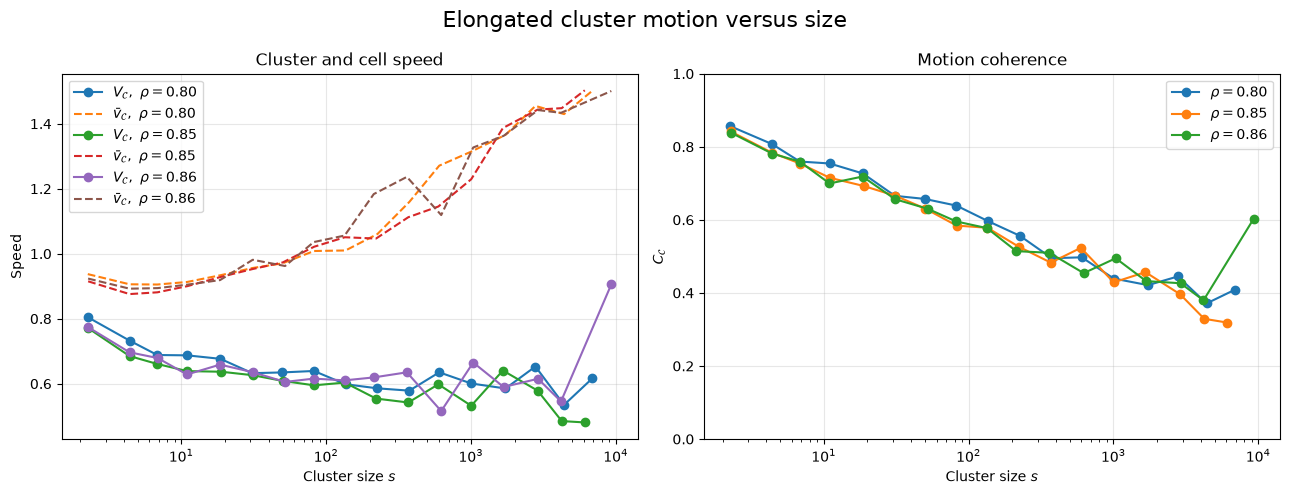

In [23]:
# Plot the cluster speed, mean cell speed, and motion coherence of elongated clusters
rho_selected = [0.80, 0.85, 0.86]

fig, axs = plt.subplots(
    1,
    2,
    figsize=(13, 5),
)

# For each selected density, plot the cluster speed, mean cell speed, and motion coherence
for rho in rho_selected:

    df_rho = motion_size[
        np.isclose(motion_size["rho"], rho)
    ].dropna()

    axs[0].plot(
        df_rho["size_mean"],
        df_rho["cluster_speed"],
        marker="o",
        label=fr"$V_\mathcal{{C}},\ \rho={rho:.2f}$",
    )

    axs[0].plot(
        df_rho["size_mean"],
        df_rho["mean_cell_speed"],
        linestyle="--",
        label=fr"$\bar{{v}}_\mathcal{{C}},\ \rho={rho:.2f}$",
    )

    axs[1].plot(
        df_rho["size_mean"],
        df_rho["motion_coherence"],
        marker="o",
        label=fr"$\rho={rho:.2f}$",
    )


axs[0].set_xscale("log")
axs[0].set_xlabel(r"Cluster size $s$")
axs[0].set_ylabel("Speed")
axs[0].set_title("Cluster and cell speed")
axs[0].grid(alpha=0.3)
axs[0].legend()


axs[1].set_xscale("log")
axs[1].set_xlabel(r"Cluster size $s$")
axs[1].set_ylabel(r"$C_{\mathcal{C}}$")
axs[1].set_ylim(0, 1)
axs[1].set_title("Motion coherence")
axs[1].grid(alpha=0.3)
axs[1].legend()


graph_title = "Elongated cluster motion versus size"
fig.suptitle(graph_title, fontsize=16)

rout_title = graph_title.lower().replace(" ", "_")

folder_name = "figures/clusters"

if not os.path.exists(folder_name):
    os.makedirs(folder_name)

plt.tight_layout()

plt.savefig(
    f"{folder_name}/{rout_title}.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

The cluster motion shows a clear dependence on cluster size.

For small elongated clusters, the collective speed $V_{\mathcal{C}}$ is relatively close to the mean cell speed $\overline{v}_{\mathcal{C}}$, giving a motion coherence $C_{\mathcal{C}}$ close to one.

As the cluster size increases, the mean cell speed increases, while the collective speed remains smaller and changes much less. As a result, $C_{\mathcal{C}}$ decreases systematically with cluster size.

This suggests that cells in large elongated clusters remain active, but an increasing part of their motion is internal and cancels when calculating the collective velocity. This could be related to curvature or internal variations of the direction of motion.

Interestingly, this behavior is quite similar for the different densities considered here, suggesting that cluster size may be more important than density for the coherence of cluster motion.

The largest-size bins should be interpreted carefully, since they contain fewer clusters.